# OPD 911 Call Volume — Exploratory Data Analysis

Structured after the EDA in Anton's CBS Predictive Analytics exam project (*Forecasting Danish
Hotel Overnight Stays After COVID-19*), adapted for this dataset's differences: hourly resolution
with two nested seasonal cycles (daily + weekly) instead of a single monthly/annual cycle, and a
count-valued series (calls per hour) instead of a continuous one.

**Scope decision (2026-09-16): post-cutover data only (2024-08-01 onward).** Earlier work
established that OPD's CAD (dispatch) system changed over on 2024-08-01, and that pre-cutover
data measures "a call" differently in at least one category (911 hang-ups). While checking for
structural breaks in the full 2021-2026 history, we also found an isolated 8-day data gap
(2023-02-08 to 02-15, ~97% of records missing — a collection gap, not a real drop in calls). Per
project decision, we don't try to patch or work around old-system data at all: this EDA runs
entirely on the post-cutover window, sidestepping both issues.

Sections mirror the reference report: **Visual EDA** (raw series, seasonal/subseries plots, MSTL
decomposition) then **Statistical Properties** (stationarity tests, Box-Cox check, ACF/PACF,
formal structural-break testing). The goal is to let this inform model choice, not just confirm the
NB GLM already in use.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import patsy
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

CALLS_PARQUET = "../Data/Our Data/harmonized_calls_2021_2026.parquet"
CAD_CUTOVER = "2024-08-01"

plt.rcParams["figure.dpi"] = 110


## 2.1 Dataset

Same source as the modeling notebook (`harmonized_calls_2021_2026.parquet`), restricted to the post-cutover window.

In [2]:
df = pd.read_parquet(CALLS_PARQUET, columns=["event_time"])
counts = df["event_time"].dt.floor("h").value_counts().sort_index()
full_index = pd.date_range(counts.index.min(), counts.index.max(), freq="h")
hourly_full = counts.reindex(full_index, fill_value=0)
hourly_full.index.name = "hour"; hourly_full.name = "calls"

hourly = hourly_full[CAD_CUTOVER:].copy()
data = hourly.reset_index()
data["hour_of_day"] = data["hour"].dt.hour
data["day_of_week"] = data["hour"].dt.dayofweek
data["day_name"] = data["hour"].dt.day_name()

print(f"Post-cutover series: {len(data):,} hours, {data['hour'].min()} to {data['hour'].max()}")
print(f"Zero-count hours: {(data['calls']==0).sum()}  |  min={data['calls'].min()}  max={data['calls'].max()}")


Post-cutover series: 16,776 hours, 2024-08-01 00:00:00 to 2026-06-30 23:00:00
Zero-count hours: 6  |  min=0  max=269


## 2.2 Visual EDA

### Raw series

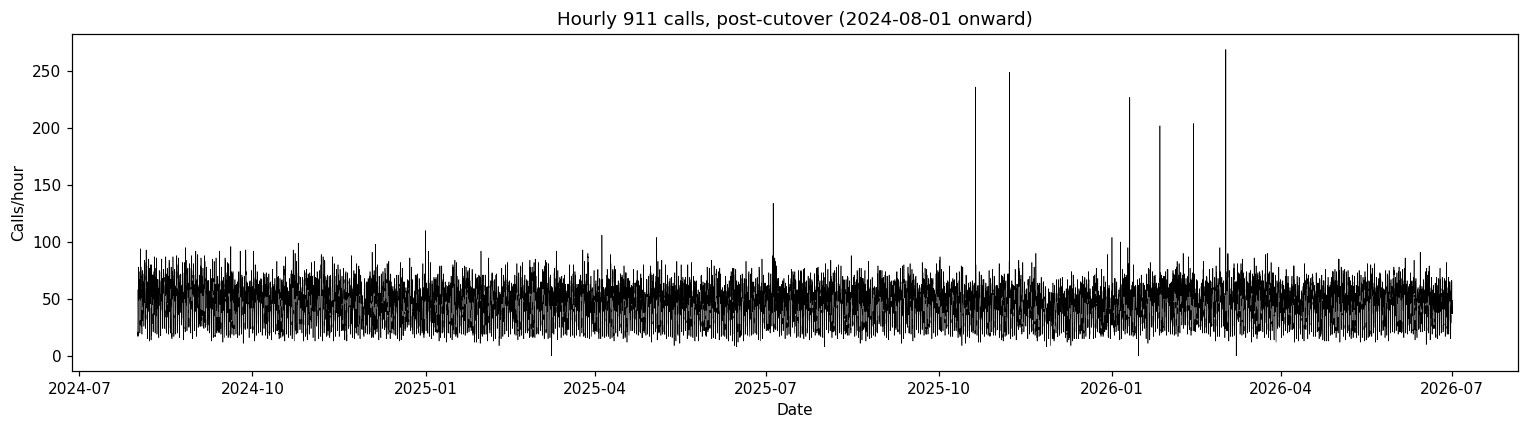

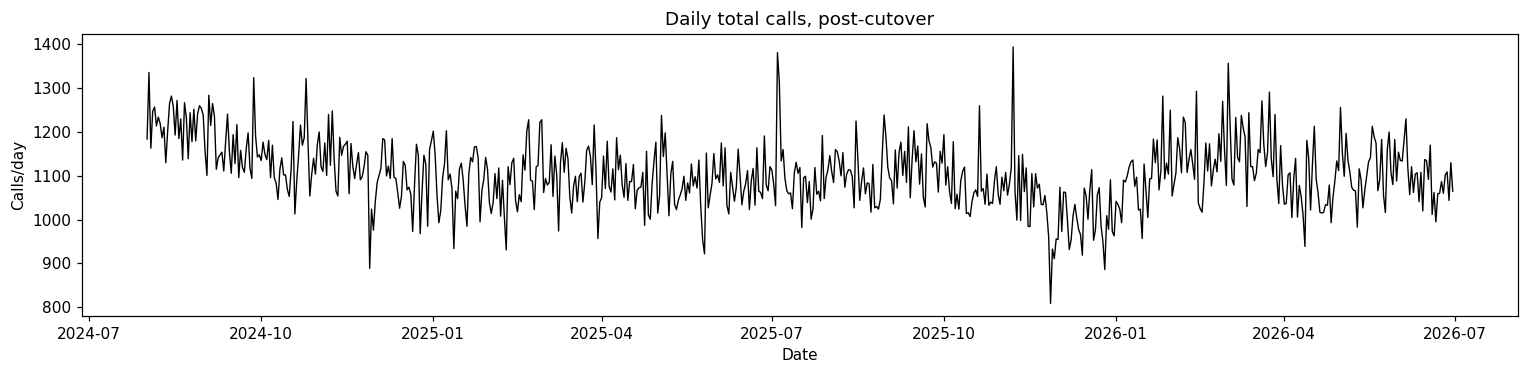

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data["hour"], data["calls"], linewidth=0.4, color="black")
ax.set_title("Hourly 911 calls, post-cutover (2024-08-01 onward)")
ax.set_xlabel("Date"); ax.set_ylabel("Calls/hour")
fig.tight_layout()
plt.show()

daily = hourly.resample("D").sum()
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(daily.index, daily.values, linewidth=0.9, color="black")
ax.set_title("Daily total calls, post-cutover")
ax.set_xlabel("Date"); ax.set_ylabel("Calls/day")
fig.tight_layout()
plt.show()


### Seasonal plot (hour-of-day, one line per weekday)

The direct analog of the reference report's seasonal plot (there: one line per year, month on the
x-axis). Here: one line per weekday, hour-of-day on the x-axis — shows both cycles at once and
whether the *shape* of a day differs by weekday, not just its level.

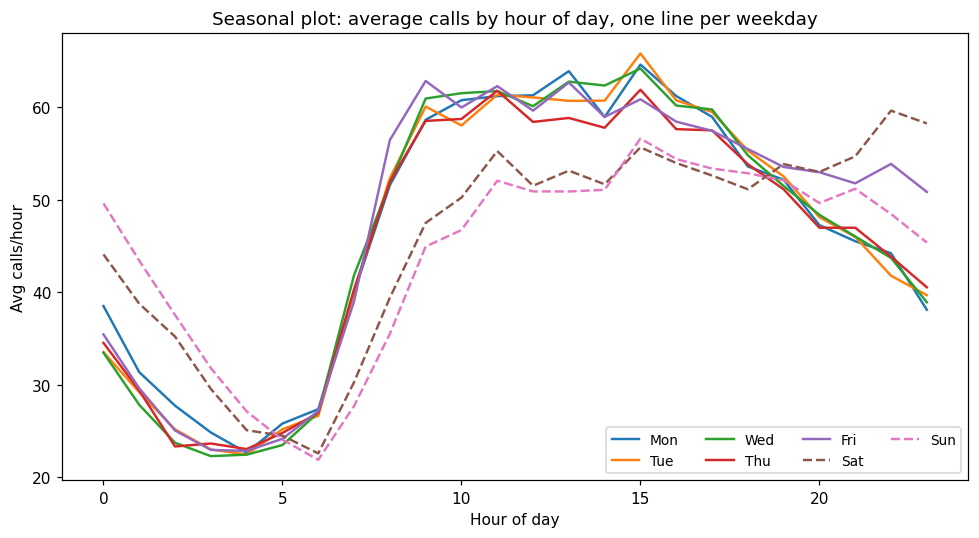

In [4]:
hod_by_dow = data.groupby(["day_of_week", "hour_of_day"])["calls"].mean().unstack(0)
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, lab in enumerate(day_labels):
    ax.plot(hod_by_dow.index, hod_by_dow[i], label=lab, linewidth=1.6,
            linestyle="--" if i >= 5 else "-")
ax.set_title("Seasonal plot: average calls by hour of day, one line per weekday")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Avg calls/hour")
ax.legend(ncol=4, fontsize=9)
fig.tight_layout()
plt.show()


### Subseries plot (per weekday, evolution over time)

For each weekday, its daily total plotted week over week — checks whether e.g. "Friday" behaves
consistently across the whole post-cutover window, or is itself drifting (the reference report's
monthly subseries plot served the same purpose for calendar months).

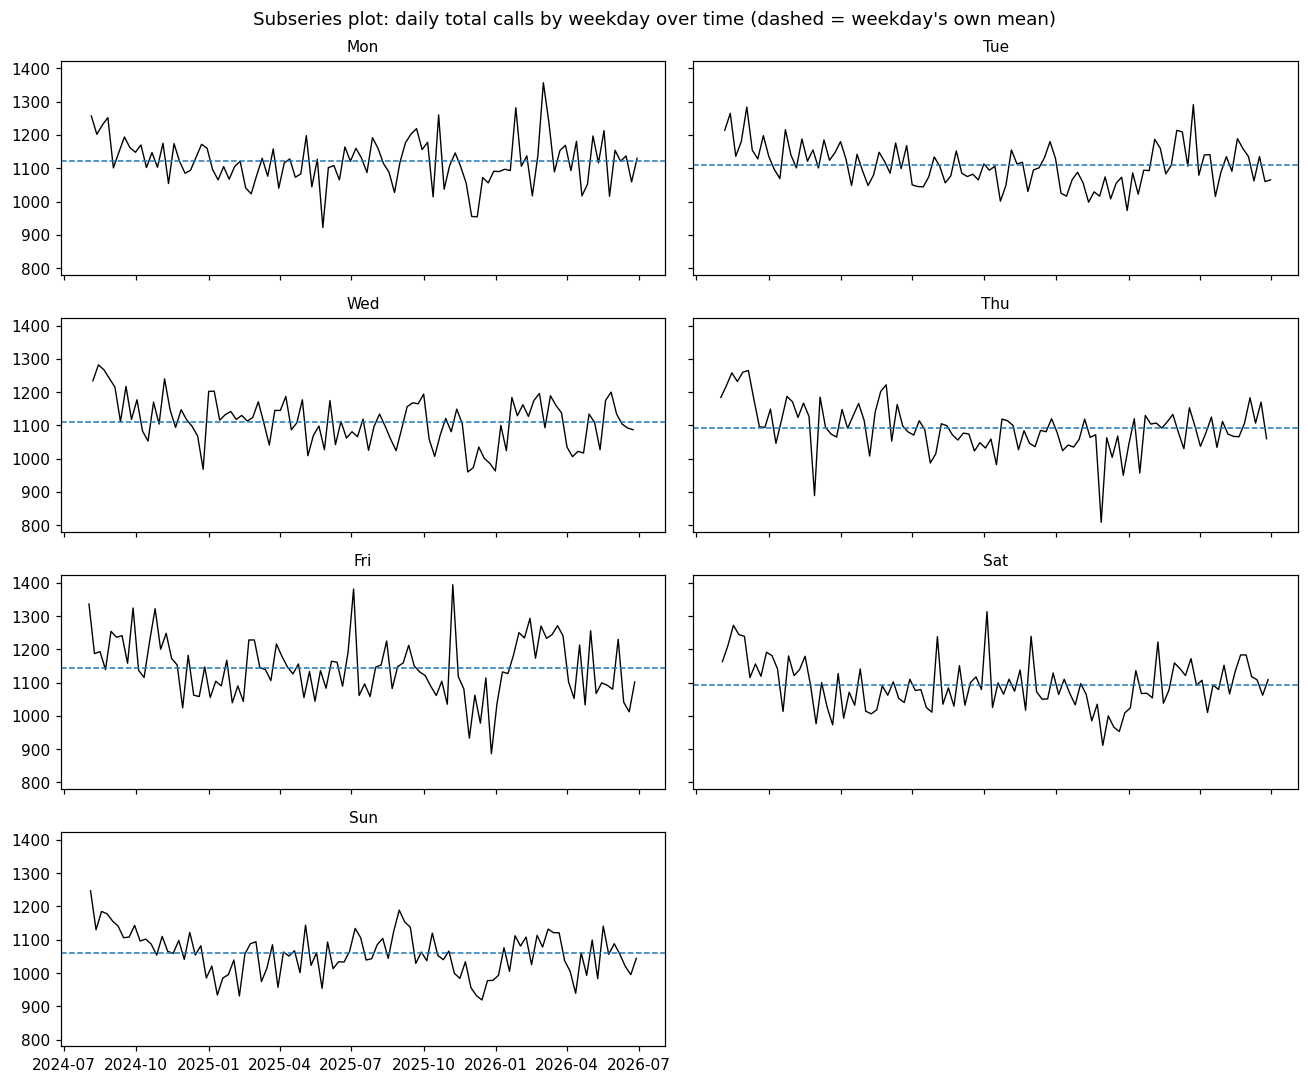

In [5]:
daily_df = daily.reset_index()
daily_df.columns = ["date", "calls"]
daily_df["dow"] = daily_df["date"].dt.dayofweek

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True, sharey=True)
for i, lab in enumerate(day_labels):
    ax = axes.flat[i]
    sub = daily_df[daily_df["dow"] == i]
    ax.plot(sub["date"], sub["calls"], linewidth=0.9, color="black")
    ax.axhline(sub["calls"].mean(), color="tab:blue", linewidth=1, linestyle="--")
    ax.set_title(lab, fontsize=10)
axes.flat[-1].axis("off")
fig.suptitle("Subseries plot: daily total calls by weekday over time (dashed = weekday's own mean)")
fig.tight_layout()
plt.show()


### MSTL decomposition (trend + daily seasonal + weekly seasonal + remainder)

The dual-seasonality analog of the reference report's single STL decomposition. Periods: 24
(daily cycle) and 168 (weekly cycle).

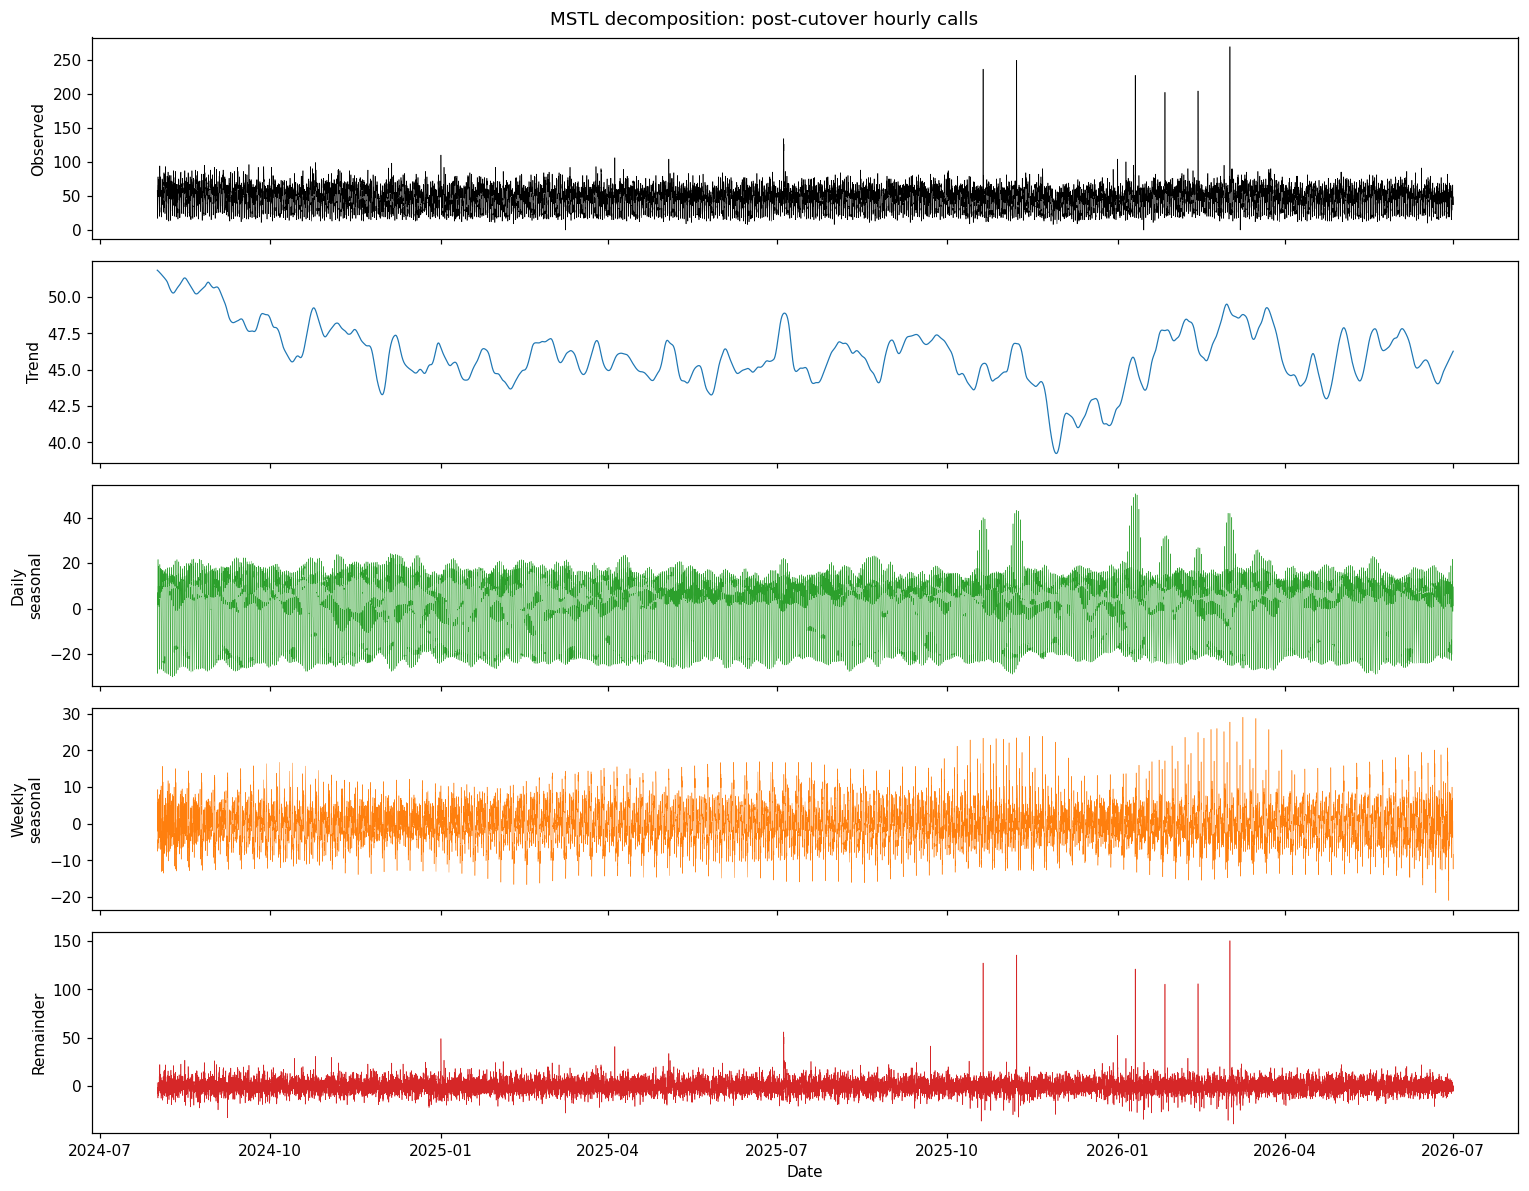

Remainder std: 7.1  | Remainder abs-max: 150.2 at 2026-03-02 13:00:00


In [6]:
mstl = MSTL(hourly.asfreq("h"), periods=[24, 168])
res = mstl.fit()

fig, axes = plt.subplots(5, 1, figsize=(14, 11), sharex=True)
axes[0].plot(res.observed, linewidth=0.4, color="black"); axes[0].set_ylabel("Observed")
axes[1].plot(res.trend, linewidth=0.8, color="tab:blue"); axes[1].set_ylabel("Trend")
axes[2].plot(res.seasonal["seasonal_24"], linewidth=0.3, color="tab:green"); axes[2].set_ylabel("Daily\nseasonal")
axes[3].plot(res.seasonal["seasonal_168"], linewidth=0.3, color="tab:orange"); axes[3].set_ylabel("Weekly\nseasonal")
axes[4].plot(res.resid, linewidth=0.4, color="tab:red"); axes[4].set_ylabel("Remainder")
axes[4].set_xlabel("Date")
fig.suptitle("MSTL decomposition: post-cutover hourly calls")
fig.tight_layout()
plt.show()

print("Remainder std:", round(float(res.resid.std()), 2), " | Remainder abs-max:", round(float(res.resid.abs().max()), 1),
      "at", res.resid.abs().idxmax())


## 2.3 Statistical Properties

### Stationarity: ADF + KPSS

In [7]:
def stationarity_report(series, label):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    print(f"[{label}]  ADF p={adf_p:.4f} (H0: unit root)   KPSS p={kpss_p:.4f} (H0: stationary)")
    return adf_p, kpss_p

print("Raw post-cutover hourly series:")
stationarity_report(data["calls"], "raw")

diff24 = data["calls"].diff(24).dropna()
print("\nAfter lag-24 (daily) differencing:")
stationarity_report(diff24, "diff24")

diff24_168 = diff24.diff(168).dropna()
print("\nAfter lag-24 THEN lag-168 (weekly) differencing:")
stationarity_report(diff24_168, "diff24+168")


Raw post-cutover hourly series:


/var/folders/wv/tll7_9b11cl01dp0rb64y21w0000gn/T/ipykernel_27711/1728430556.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


[raw]  ADF p=0.0000 (H0: unit root)   KPSS p=0.0100 (H0: stationary)

After lag-24 (daily) differencing:


/var/folders/wv/tll7_9b11cl01dp0rb64y21w0000gn/T/ipykernel_27711/1728430556.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


[diff24]  ADF p=0.0000 (H0: unit root)   KPSS p=0.1000 (H0: stationary)

After lag-24 THEN lag-168 (weekly) differencing:


[diff24+168]  ADF p=0.0000 (H0: unit root)   KPSS p=0.1000 (H0: stationary)


/var/folders/wv/tll7_9b11cl01dp0rb64y21w0000gn/T/ipykernel_27711/1728430556.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")


(0.0, np.float64(0.1))

### Box-Cox applicability check

The reference report used Box-Cox to stabilize multiplicative seasonality before SARIMA. Two
differences here: (1) count data has zero-valued hours (6 in this window), and raw Box-Cox
requires strictly positive values, so we test on `calls + 1`; (2) an NB/Poisson GLM already models
the mean-variance relationship for counts directly via its link function, so a variance-stabilizing
transform may simply be unnecessary for that model family — this check is about informing that
choice, not assuming SARIMA is the destination.

Best-fit Box-Cox lambda (on calls+1): 0.75
Correlation between daily mean and daily variance: 0.501


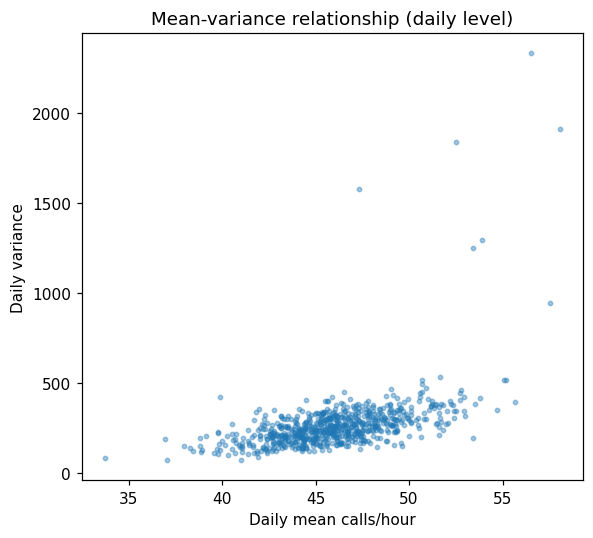

In [8]:
lam_range = np.linspace(-1, 2, 61)
llf = [stats.boxcox_llf(l, data["calls"] + 1) for l in lam_range]
best_lambda = lam_range[np.argmax(llf)]
print(f"Best-fit Box-Cox lambda (on calls+1): {best_lambda:.2f}")

# Does variance scale with level? (motivates whether a variance-stabilizing transform matters at all)
by_hour = data.groupby(data["hour"].dt.floor("D"))["calls"].agg(["mean", "var"])
corr = by_hour["mean"].corr(by_hour["var"])
print(f"Correlation between daily mean and daily variance: {corr:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(by_hour["mean"], by_hour["var"], s=8, alpha=0.4, color="tab:blue")
ax.set_xlabel("Daily mean calls/hour"); ax.set_ylabel("Daily variance")
ax.set_title("Mean-variance relationship (daily level)")
fig.tight_layout()
plt.show()


### ACF / PACF

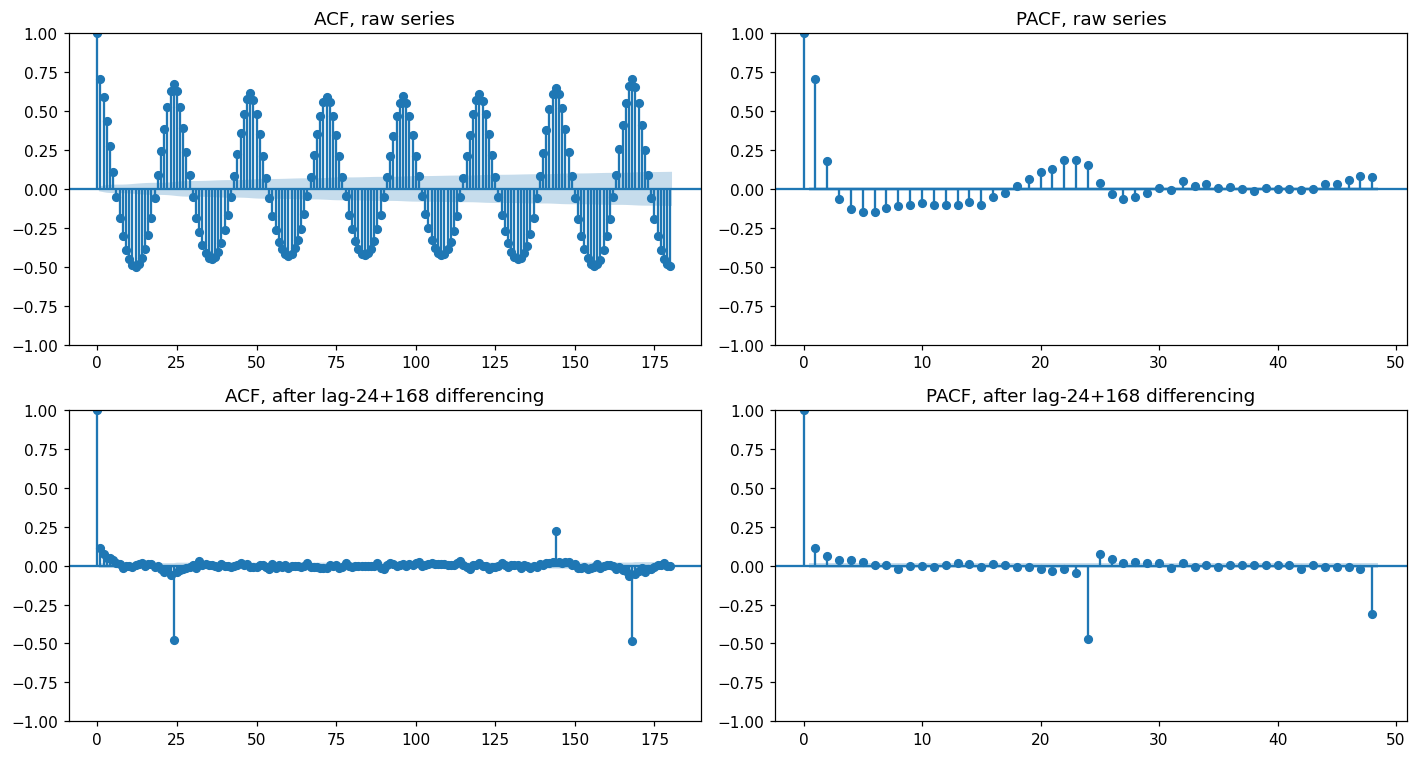

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(data["calls"], lags=180, ax=axes[0,0], title="ACF, raw series")
plot_pacf(data["calls"], lags=48, ax=axes[0,1], title="PACF, raw series", method="ywm")
plot_acf(diff24_168, lags=180, ax=axes[1,0], title="ACF, after lag-24+168 differencing")
plot_pacf(diff24_168, lags=48, ax=axes[1,1], title="PACF, after lag-24+168 differencing", method="ywm")
fig.tight_layout()
plt.show()


### Structural break testing: Chow test + Sup-F scan

Direct analog of the reference report's Chow/Sup-F approach (no ready-made Python equivalent
of R's `strucchange`, so implemented directly: OLS of `log1p(calls) ~ hour_of_day + day_of_week`,
comparing pooled vs. split-sample SSR). Run within the post-cutover window only, to check whether
there's an internal break we should know about (e.g. the hang-up-call volume shift that continued
settling into Nov 2024, discovered separately) before finalizing the training window.

Sup-F max: F=7.65 (p=1.11e-16) at 2024-11-22


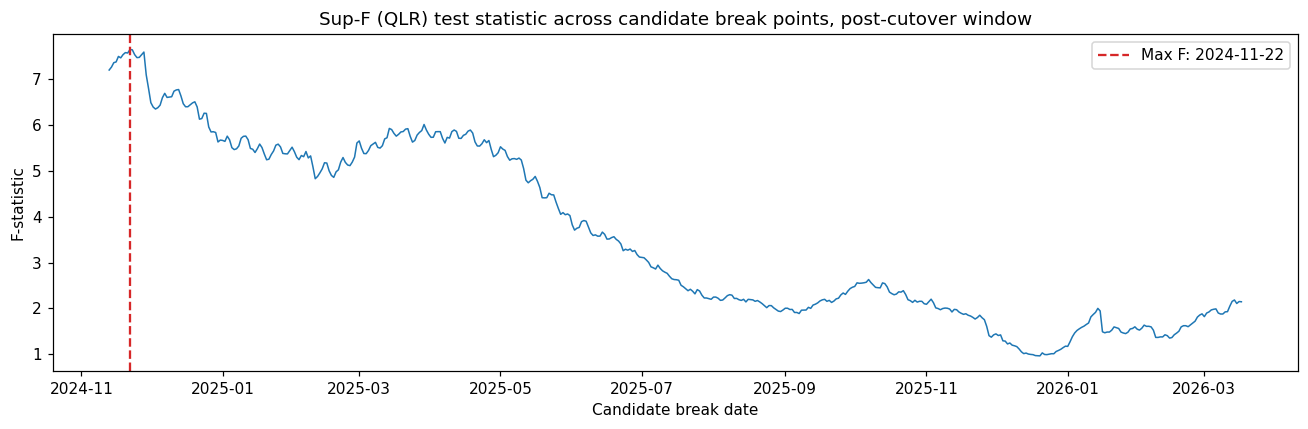

In [10]:
data["log_calls"] = np.log1p(data["calls"])
y, X = patsy.dmatrices("log_calls ~ C(hour_of_day) + C(day_of_week)", data=data, return_type="dataframe")
y = y.values.ravel(); X = X.values
n, k = X.shape

def ssr_fit(Xs, ys):
    beta, *_ = np.linalg.lstsq(Xs, ys, rcond=None)
    return np.sum((ys - Xs @ beta) ** 2)

ssr_pooled = ssr_fit(X, y)

def chow_F(split_idx):
    n1, n2 = split_idx, n - split_idx
    if n1 < 200 or n2 < 200:
        return np.nan
    ssr1 = ssr_fit(X[:split_idx], y[:split_idx])
    ssr2 = ssr_fit(X[split_idx:], y[split_idx:])
    return ((ssr_pooled - (ssr1 + ssr2)) / k) / ((ssr1 + ssr2) / (n - 2 * k))

day_starts = np.arange(0, n, 24)
lo, hi = int(0.15 * len(day_starts)), int(0.85 * len(day_starts))
candidates = day_starts[lo:hi]
Fs = np.array([chow_F(idx) for idx in candidates])

best = np.nanargmax(Fs)
best_idx = candidates[best]
best_date = data["hour"].iloc[best_idx]
p_at_best = 1 - stats.f.cdf(Fs[best], k, n - 2*k)
print(f"Sup-F max: F={Fs[best]:.2f} (p={p_at_best:.2e}) at {best_date.date()}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(data["hour"].iloc[candidates], Fs, linewidth=1, color="tab:blue")
ax.axvline(best_date, color="tab:red", linestyle="--", label=f"Max F: {best_date.date()}")
ax.set_title("Sup-F (QLR) test statistic across candidate break points, post-cutover window")
ax.set_xlabel("Candidate break date"); ax.set_ylabel("F-statistic")
ax.legend()
fig.tight_layout()
plt.show()


## Summary — for discussion, not a final answer

This is a factual recap of what the EDA found; how to act on it is a modeling decision to make
together, not something to decide unilaterally here.

- *(fill in after running: stationarity conclusion, Box-Cox conclusion, ACF/PACF structure, and
  where/whether Sup-F found an internal break within the post-cutover window)*
